In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path
import xgboost as xgb

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,81.374162,0.243345,False
1,duration_months_woe,40.639132,0.23402,False
2,credit_history_woe,40.399187,0.376188,True
3,savings_account_bonds_woe,30.802473,0.243345,False
4,credit_amount_woe,28.469128,0.23402,False


In [5]:
event = 'bad'

## make dummies

In [6]:
with open("../data/01_dic_feat_names.pkl", "rb") as file:
    feat_names = pickle.load(file)

In [7]:
X_raw= df[feat_names['raw']]
y = df[event]

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_columns = X_raw.select_dtypes(exclude="number").columns
numeric_columns = X_raw.select_dtypes(include="number").columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        ("numeric", "passthrough", numeric_columns)
    ]
)

In [9]:
train_array = preprocessor.fit_transform(X_raw)

# Apply the exact same dummy columns to the new dataset
# new_encoded = preprocessor.transform(new_df)

### save dummy encoder

In [10]:
type(preprocessor)

sklearn.compose._column_transformer.ColumnTransformer

In [11]:
import joblib

joblib.dump(preprocessor, "../data/02b_dummy_preprocessor.pkl")

['../data/02b_dummy_preprocessor.pkl']

### make into dataframe

In [12]:
# dont need to but make sit easier to look at if you need 

pre_names = preprocessor.get_feature_names_out()

X = pd.DataFrame(
    train_array,
    columns=pre_names,
    index=df.index
)


## optimization

In [13]:
import numpy as np
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score


def objective(trial):
    params = params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",

    # Let early stopping determine the final number of trees
    "n_estimators": 5000,

    "max_depth": trial.suggest_int(
        "max_depth", 2, 8
    ),

    "learning_rate": trial.suggest_float(
        "learning_rate", 0.01, 0.15, log=True
    ),

    "min_child_weight": trial.suggest_float(
        "min_child_weight", 1, 30, log=True
    ),

    "subsample": trial.suggest_float(
        "subsample", 0.5, 1.0
    ),

    "colsample_bytree": trial.suggest_float(
        "colsample_bytree", 0.7, 1.0
    ),

    "gamma": trial.suggest_float(
        "gamma", 1e-8, 10, log=True
    ),

    "reg_alpha": trial.suggest_float(
        "reg_alpha", 1e-8, 10, log=True
    ),

    "reg_lambda": trial.suggest_float(
        "reg_lambda", 0.1, 100, log=True
    ),

    # Additional useful controls
    "max_delta_step": trial.suggest_float(
        "max_delta_step", 0, 5
    ),

    "max_bin": trial.suggest_int(
        "max_bin", 128, 512
    ),

    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
}

    
    
    # {
    #     "objective": "binary:logistic",
    #     "eval_metric": "aucpr",
    #     "tree_method": "hist",

    #     # "n_estimators": trial.suggest_int(
    #     #     "n_estimators", 200, 2000
    #     # ),

    #     # Large upper limit; early stopping determines the useful number
    #     "n_estimators": 5000,
        
    #     "max_depth": trial.suggest_int(
    #         "max_depth", 2, 10
    #     ),
    #     "learning_rate": trial.suggest_float(
    #         "learning_rate", 0.005, 0.2, log=True
    #     ),
    #     "min_child_weight": trial.suggest_float(
    #         "min_child_weight", 1, 20, log=True
    #     ),
    #     "subsample": trial.suggest_float(
    #         "subsample", 0.6, 1.0
    #     ),
    #     "colsample_bytree": trial.suggest_float(
    #         "colsample_bytree", 0.6, 1.0
    #     ),
    #     "gamma": trial.suggest_float(
    #         "gamma", 0, 10
    #     ),
    #     "reg_alpha": trial.suggest_float(
    #         "reg_alpha", 1e-8, 10, log=True
    #     ),
    #     "reg_lambda": trial.suggest_float(
    #         "reg_lambda", 1e-8, 10, log=True
    #     ),

    #     "random_state": 42,
    #     "n_jobs": -1,
        
    #     "early_stopping_rounds": 100,
    # }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_pr_aucs = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        predictions = model.predict_proba(X_valid)[:, 1]

        # Average precision is commonly used as the PR-AUC summary metric
        pr_auc = average_precision_score(
            y_valid,
            predictions
        )

        fold_pr_aucs.append(pr_auc)

        # Report the mean PR-AUC achieved so far
        trial.report(
            np.mean(fold_pr_aucs),
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_pr_aucs)

In [14]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-10 20:51:18,500] A new study created in memory with name: no-name-db01631d-3182-4e71-bcf1-53288312e6a2


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-10 20:51:21,012] Trial 0 finished with value: 0.6456604739563261 and parameters: {'max_depth': 4, 'learning_rate': 0.13125830316209655, 'min_child_weight': 12.057126287443763, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.7468055921327309, 'gamma': 2.5348407664333426e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 39.67605077052987, 'max_delta_step': 3.005575058716044, 'max_bin': 400}. Best is trial 0 with value: 0.6456604739563261.
[I 2026-09-10 20:51:21,313] Trial 1 finished with value: 0.6364090922520573 and parameters: {'max_depth': 2, 'learning_rate': 0.13826189316223852, 'min_child_weight': 16.967533607196547, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.7545474901621302, 'gamma': 4.4734294104626844e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 3.752055855124281, 'max_delta_step': 2.1597250932105787, 'max_bin': 240}. Best is trial 0 with value: 0.6456604739563261.
[I 2026-09-10 20:51:21,879] Trial 2 finished with value: 0.64838588162

In [15]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.6847165444772523
Best parameters:
{'max_depth': 8, 'learning_rate': 0.123857906037659, 'min_child_weight': 1.7701288525626249, 'subsample': 0.6314791985241804, 'colsample_bytree': 0.7212201635606491, 'gamma': 4.5390327353059935e-07, 'reg_alpha': 9.264876429026766e-05, 'reg_lambda': 47.47320730346604, 'max_delta_step': 1.896886209174368, 'max_bin': 321}


## optimization summary

In [16]:
import matplotlib.pyplot as plt

In [17]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_1894720/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


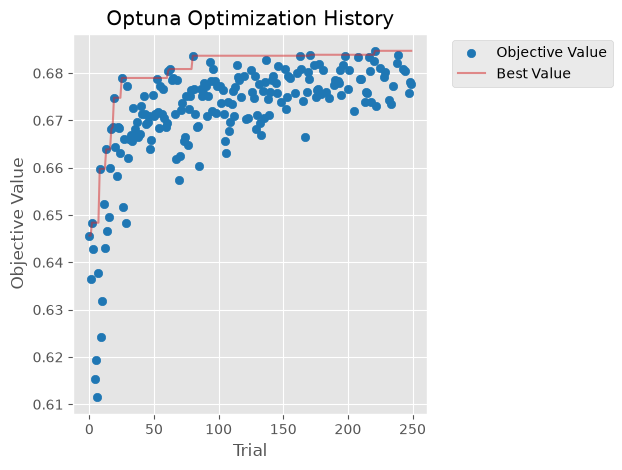

In [18]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894720/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


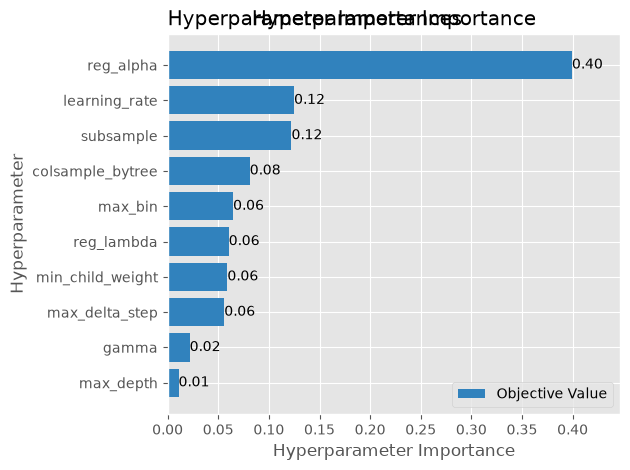

In [19]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894720/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_1894720/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


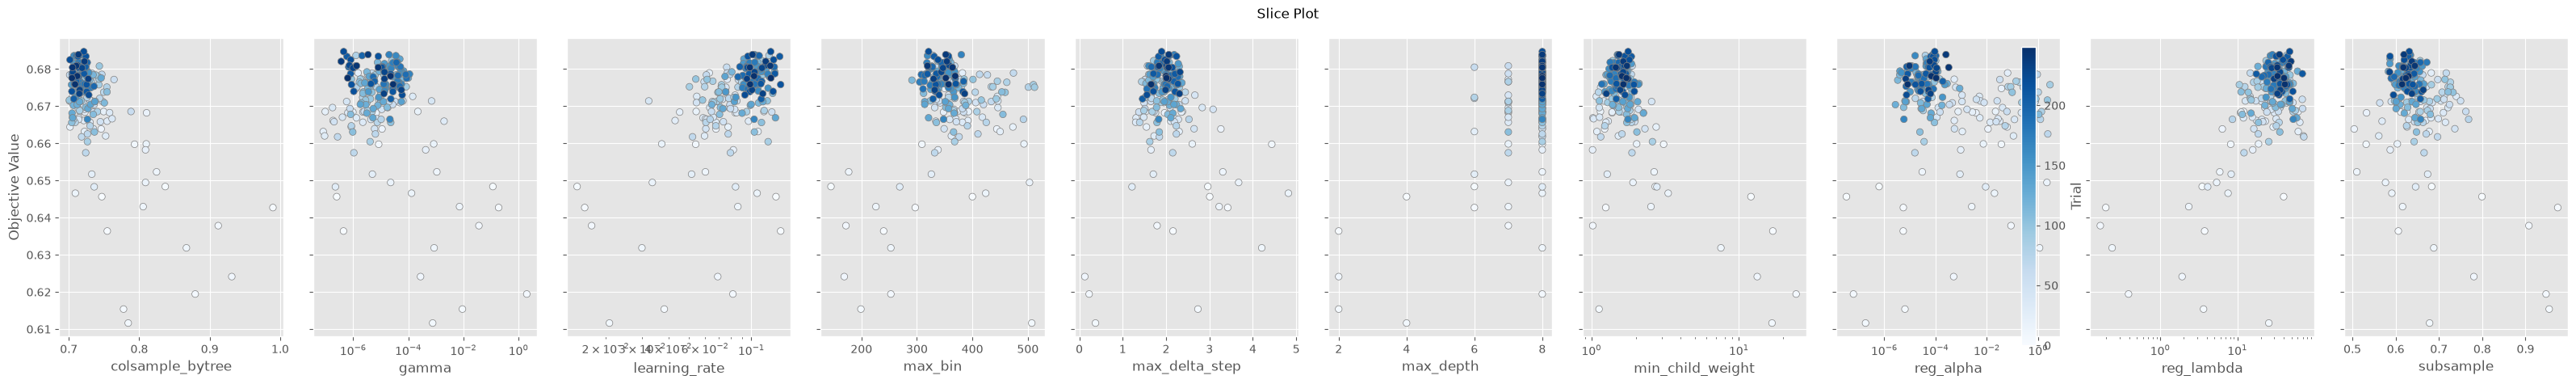

In [20]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894720/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


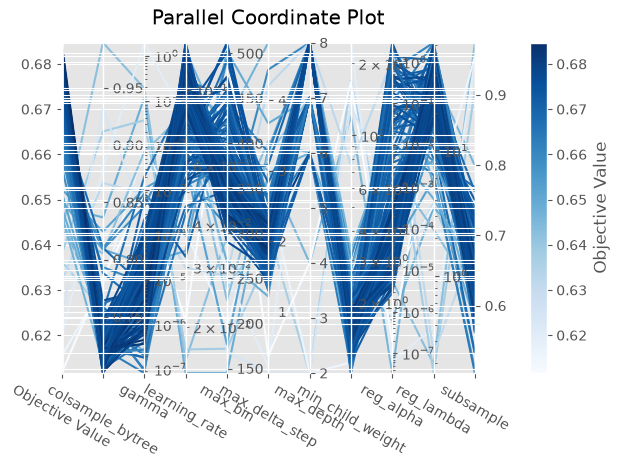

In [21]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894720/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


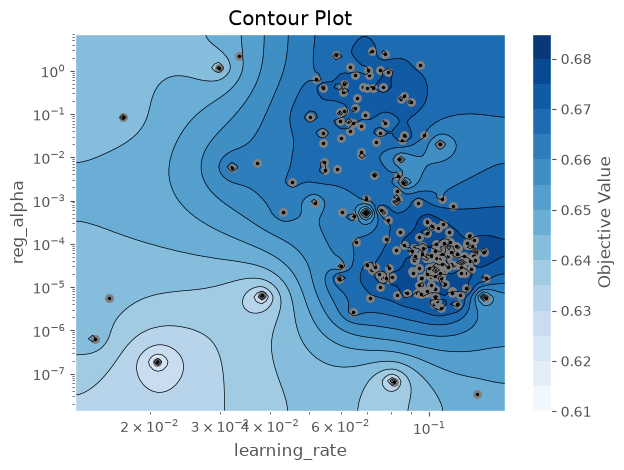

In [22]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [23]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [24]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_bin,params_max_delta_step,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
221,221,0.684717,2026-09-10 20:53:12.699564,2026-09-10 20:53:13.168480,0 days 00:00:00.468916,0.721220,4.539033e-07,0.123858,321,1.896886,8,1.770129,0.000093,47.473207,0.631479,"{""colsample_bytree"": 0.7212201635606491, ""gamm...",COMPLETE
239,239,0.683904,2026-09-10 20:53:19.794661,2026-09-10 20:53:20.310380,0 days 00:00:00.515719,0.713680,3.471207e-06,0.101281,352,2.062184,8,1.534720,0.000254,34.993439,0.619083,"{""colsample_bytree"": 0.7136802467627703, ""gamm...",COMPLETE
171,171,0.683881,2026-09-10 20:52:48.917412,2026-09-10 20:52:49.384928,0 days 00:00:00.467516,0.717190,2.008511e-05,0.103605,380,2.186800,8,1.497919,0.000077,28.366796,0.633836,"{""colsample_bytree"": 0.7171895423509269, ""gamm...",COMPLETE
80,80,0.683676,2026-09-10 20:52:04.336168,2026-09-10 20:52:04.802448,0 days 00:00:00.466280,0.716245,1.266571e-06,0.121479,329,1.947302,8,1.760872,0.000040,43.244829,0.634225,"{""colsample_bytree"": 0.7162453451013763, ""gamm...",COMPLETE
198,198,0.683623,2026-09-10 20:53:02.536809,2026-09-10 20:53:02.986573,0 days 00:00:00.449764,0.711115,2.109461e-06,0.109044,356,2.071723,8,1.513466,0.000102,35.310630,0.627537,"{""colsample_bytree"": 0.7111148202081771, ""gamm...",COMPLETE
163,163,0.683612,2026-09-10 20:52:44.908735,2026-09-10 20:52:45.385968,0 days 00:00:00.477233,0.707265,3.548711e-05,0.106690,319,1.874158,8,1.714747,0.000016,26.686582,0.631626,"{""colsample_bytree"": 0.7072646200054539, ""gamm...",COMPLETE
216,216,0.683445,2026-09-10 20:53:10.324706,2026-09-10 20:53:10.891105,0 days 00:00:00.566399,0.724232,8.188829e-06,0.096259,357,2.240594,8,1.679323,0.000080,31.634606,0.586937,"{""colsample_bytree"": 0.7242323252847602, ""gamm...",COMPLETE
208,208,0.683398,2026-09-10 20:53:06.501441,2026-09-10 20:53:06.954196,0 days 00:00:00.452755,0.712972,5.949771e-07,0.136855,331,1.828278,8,1.861568,0.000065,44.477734,0.629510,"{""colsample_bytree"": 0.7129718578031563, ""gamm...",COMPLETE
137,137,0.682719,2026-09-10 20:52:34.943356,2026-09-10 20:52:35.555509,0 days 00:00:00.612153,0.705092,4.930565e-05,0.092096,358,1.839909,8,1.667394,0.000043,44.032279,0.587112,"{""colsample_bytree"": 0.7050923093803314, ""gamm...",COMPLETE
220,220,0.682505,2026-09-10 20:53:12.200652,2026-09-10 20:53:12.697944,0 days 00:00:00.497292,0.701605,8.164808e-07,0.127882,338,1.972807,8,1.805154,0.000090,38.938461,0.619836,"{""colsample_bytree"": 0.7016054709658819, ""gamm...",COMPLETE


# fit best model

In [25]:
best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7212201635606491
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

In [26]:
X.columns

Index(['categorical__checking_account_status_ge200 DM',
       'categorical__checking_account_status_lt0 DM',
       'categorical__checking_account_status_no account',
       'categorical__credit_history_critical or other credit',
       'categorical__credit_history_current credit paid',
       'categorical__credit_history_no credit or all paid',
       'categorical__credit_history_past payment delays',
       'categorical__purpose_business', 'categorical__purpose_education',
       'categorical__purpose_furniture or equipment',
       'categorical__purpose_new car', 'categorical__purpose_other',
       'categorical__purpose_radio or TV', 'categorical__purpose_repairs',
       'categorical__purpose_retraining', 'categorical__purpose_used car',
       'categorical__savings_account_bonds_500 to 1000 DM',
       'categorical__savings_account_bonds_ge1000 DM',
       'categorical__savings_account_bonds_lt100 DM',
       'categorical__savings_account_bonds_unknown or no savings',
       'ca

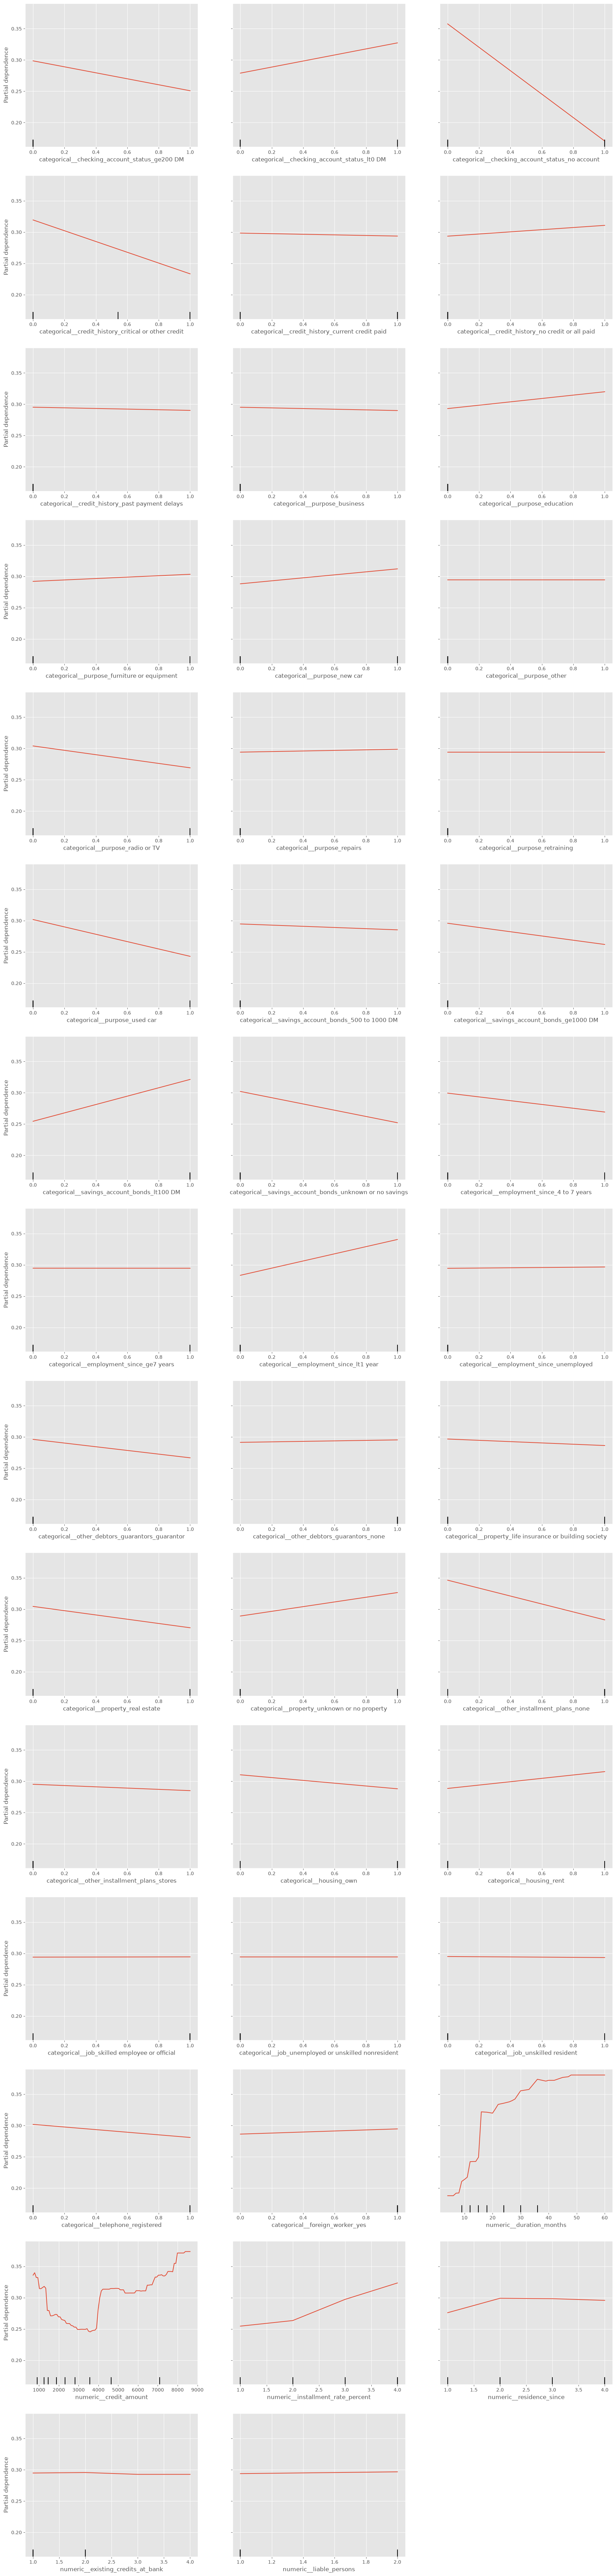

In [27]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=X.columns,
    n_cols=3
)

n_rows = (len(X.columns) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [28]:
models['xgb raw'] = final_model

In [29]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)